In [7]:
#Activity 1
#Run the libraries
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# 2. Load dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# 2. Basic data cleaning
# TotalCharges has blank values, so convert it to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing TotalCharges
df = df.dropna()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [9]:
# 3. Prepare features and target

# Drop customerID because it is only an identifier
X = df.drop(["customerID", "Churn"], axis=1)

# Convert target into numeric format
# No = 0, Yes = 1
y = df["Churn"].map({"No": 0, "Yes": 1})

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numeric_cols))

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
# 4. Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [11]:
# 5. Preprocessing + Baseline SVM model

# Numerical columns are scaled
# Categorical columns are converted using one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Baseline SVM uses default SVC settings
baseline_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC())
])

In [12]:
# 6. Train baseline SVM model

baseline_svm.fit(X_train, y_train)

# Predict test data
y_pred = baseline_svm.predict(X_test)

In [13]:
# 7. Evaluate baseline model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== BASELINE SVM MODEL PERFORMANCE =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

===== BASELINE SVM MODEL PERFORMANCE =====
Accuracy : 0.7918
Precision: 0.6401
Recall   : 0.4947
F1 Score : 0.5581


In [14]:
#check for overfitting
train_pred = baseline_svm.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)
print(train_accuracy)

0.8200888888888889


In [15]:
# ============================================================
# ACTIVITY 2: ENHANCED SVM USING OPTUNA
# Automated Hyperparameter Tuning
# ============================================================

!pip install optuna -q

In [16]:
import optuna
from sklearn.model_selection import cross_val_score

In [17]:
# ============================================================
# 1. Define Optuna objective function
# ============================================================

def objective(trial):

    # ENHANCEMENT 1: Tune kernel type
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])

    # ENHANCEMENT 2: Tune C value
    C = trial.suggest_float("C", 0.01, 100, log=True)

    # ENHANCEMENT 3: Tune gamma for RBF kernel
    if kernel == "rbf":
        gamma = trial.suggest_float("gamma", 0.0001, 1, log=True)
    else:
        gamma = "scale"

    # ENHANCEMENT 4: Tune class weight to improve churn detection
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    enhanced_svm = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            class_weight=class_weight
        ))
    ])

    # ENHANCEMENT 5: Use cross-validation and F1-score
    score = cross_val_score(
        enhanced_svm,
        X_train,
        y_train,
        cv=3,
        scoring="f1"
    ).mean()

    return score

In [18]:
# ============================================================
# 2. Run Optuna automated search
# ============================================================

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best F1 Score from Optuna:", study.best_value)
print("Best Parameters:")
print(study.best_params)

[I 2026-04-28 10:26:54,958] A new study created in memory with name: no-name-84adb2c6-fe42-417e-b975-b25f2acd167e
[I 2026-04-28 10:26:59,934] Trial 0 finished with value: 0.608621236380963 and parameters: {'kernel': 'rbf', 'C': 0.010741482558283508, 'gamma': 0.011779743935429245, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.608621236380963.
[I 2026-04-28 10:27:01,533] Trial 1 finished with value: 0.6002438190275274 and parameters: {'kernel': 'linear', 'C': 0.08242532443527391, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.608621236380963.
[I 2026-04-28 10:27:03,231] Trial 2 finished with value: 0.6002438190275274 and parameters: {'kernel': 'linear', 'C': 0.09272107530464645, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.608621236380963.
[I 2026-04-28 10:27:04,947] Trial 3 finished with value: 0.6065350740862505 and parameters: {'kernel': 'linear', 'C': 0.015095593629263238, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.60862123638096

Best F1 Score from Optuna: 0.6232395002193962
Best Parameters:
{'kernel': 'rbf', 'C': 0.17811647510250314, 'gamma': 0.04337125509211622, 'class_weight': 'balanced'}


In [19]:
# ============================================================
# 3. Build final enhanced SVM using best parameters
# ============================================================

best_params = study.best_params

enhanced_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel=best_params["kernel"],
        C=best_params["C"],
        gamma=best_params.get("gamma", "scale"),
        class_weight=best_params["class_weight"]
    ))
])

enhanced_svm.fit(X_train, y_train)

enhanced_pred = enhanced_svm.predict(X_test)

In [20]:
# ============================================================
# 4. Evaluate enhanced SVM model
# ============================================================

enhanced_accuracy = accuracy_score(y_test, enhanced_pred)
enhanced_precision = precision_score(y_test, enhanced_pred)
enhanced_recall = recall_score(y_test, enhanced_pred)
enhanced_f1 = f1_score(y_test, enhanced_pred)

print("===== OPTUNA ENHANCED SVM MODEL PERFORMANCE =====")
print("Accuracy :", round(enhanced_accuracy, 4))
print("Precision:", round(enhanced_precision, 4))
print("Recall   :", round(enhanced_recall, 4))
print("F1 Score :", round(enhanced_f1, 4))

===== OPTUNA ENHANCED SVM MODEL PERFORMANCE =====
Accuracy : 0.7186
Precision: 0.4822
Recall   : 0.7968
F1 Score : 0.6008


In [21]:
# ============================================================
# 5. Compare Baseline SVM vs Optuna Enhanced SVM
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Baseline SVM", "Optuna Enhanced SVM"],
    "Accuracy": [accuracy, enhanced_accuracy],
    "Precision": [precision, enhanced_precision],
    "Recall": [recall, enhanced_recall],
    "F1 Score": [f1, enhanced_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline SVM,0.791756,0.640138,0.494652,0.558069
1,Optuna Enhanced SVM,0.718550,0.482201,0.796791,0.600806


In [22]:
# ============================================================
# ACTIVITY 3: HYBRID MODEL USING OPTUNA-TUNED SVM + RANDOM FOREST
# Continue after Activity 2
# Uses best_params from Optuna study
# ============================================================
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

In [23]:
# ============================================================
# 3. Hybrid Voting Model
# SVM + Random Forest
# ============================================================
# ============================================================
# Build SVM using Optuna best parameters
# ============================================================

optuna_svm = SVC(
    kernel=best_params["kernel"],
    C=best_params["C"],
    gamma=best_params.get("gamma", "scale"),
    class_weight=best_params["class_weight"],
    probability=True,      # needed for soft voting
    random_state=42
)

hybrid_model = VotingClassifier(
    estimators=[
        ("svm", optuna_svm),
        ("rf", rf_model)
    ],
    voting="soft"   # use probability averaging
)

In [24]:
# ============================================================
# 4. Full Pipeline
# ============================================================

hybrid_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("hybrid_model", hybrid_model)
])

In [34]:
# ============================================================
# 5. Train Hybrid Model
# ============================================================

hybrid_pipeline.fit(X_train, y_train)

hybrid_pred = hybrid_pipeline.predict(X_test)

In [38]:
# ============================================================
# 6. Evaluate Hybrid Model
# ============================================================

hybrid_accuracy = accuracy_score(y_test, hybrid_pred)
hybrid_precision = precision_score(y_test, hybrid_pred)
hybrid_recall = recall_score(y_test, hybrid_pred)
hybrid_f1 = f1_score(y_test, hybrid_pred)

print("===== HYBRID MODEL: OPTUNA SVM + RANDOM FOREST =====")
print("Accuracy :", round(hybrid_accuracy,4))
print("Precision:", round(hybrid_precision,4))
print("Recall   :", round(hybrid_recall,4))
print("F1 Score :", round(hybrid_f1,4))


===== HYBRID MODEL: OPTUNA SVM + RANDOM FOREST =====
Accuracy : 0.7811
Precision: 0.573
Recall   : 0.6925
F1 Score : 0.6271


In [39]:
# ============================================================
# 7. Final Comparison
# baseline metrics from Activity 1:
# accuracy, precision, recall, f1
#
# optuna metrics from Activity 2:
# enhanced_accuracy, enhanced_precision,
# enhanced_recall, enhanced_f1
# ============================================================

comparison = pd.DataFrame({
    "Model":[
        "Baseline SVM",
        "Optuna Enhanced SVM",
        "Hybrid Optuna SVM + RF"
    ],
    "Accuracy":[
        accuracy,
        enhanced_accuracy,
        hybrid_accuracy
    ],
    "Precision":[
        precision,
        enhanced_precision,
        hybrid_precision
    ],
    "Recall":[
        recall,
        enhanced_recall,
        hybrid_recall
    ],
    "F1 Score":[
        f1,
        enhanced_f1,
        hybrid_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline SVM,0.791756,0.640138,0.494652,0.558069
1,Optuna Enhanced SVM,0.718550,0.482201,0.796791,0.600806
2,Hybrid Optuna SVM + RF,0.781095,0.573009,0.692513,0.627119


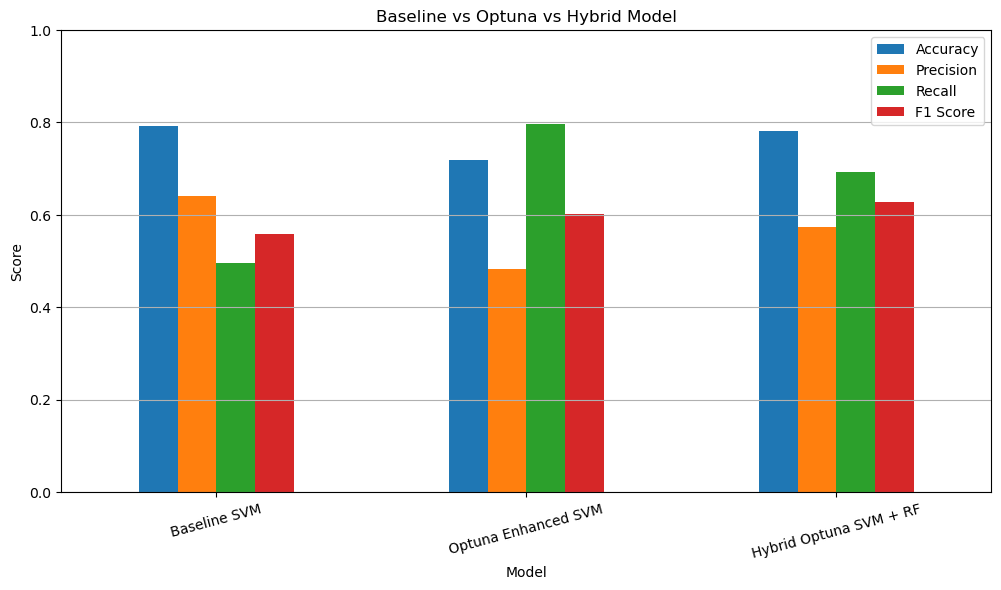

In [40]:
# ============================================================
# 8. Plot Final Results
# ============================================================

import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(kind="bar", figsize=(12,6))

plt.title("Baseline vs Optuna vs Hybrid Model")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()